In [2]:
# quantum lessons part 2 - intro
# demo 1 - hadamard gate circuit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1, 1)

qc.h(0)
qc.measure(0, 0)

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts)

{'0': 515, '1': 485}


In [3]:
# part 2.1
# demo 1 - simulation of a qubit
import numpy as np

ket_0 = np.array([1, 0], dtype=complex)

H = (1 / np.sqrt(2)) * np.array([
    [1, 1],
    [1, -1]
], dtype=complex)

ket_plus = H @ ket_0

print(ket_plus)
print("Probabilities:", np.abs(ket_plus) ** 2)

[0.70710678+0.j 0.70710678+0.j]
Probabilities: [0.5 0.5]


In [4]:
# demo 2 - 2.1 - superposition
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [5]:
# demo 3 - 2.1 - measure superposition
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

print(result.get_counts())

{'1': 488, '0': 512}


In [6]:
# part 2.2
# demo 1 - 1 qubit circuit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc)
print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [7]:
# part 2.2 - demo 2 - bell circuit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [9]:
# demo 3 - 2.2 - measuring bell circuit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

print(result.get_counts())

{'11': 497, '00': 503}


In [10]:
# part 2.3 - demo 1 - bell circuit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [11]:
# demo 2 - 2.3 - measuring bell state
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

print(result.get_counts())

{'00': 499, '11': 501}


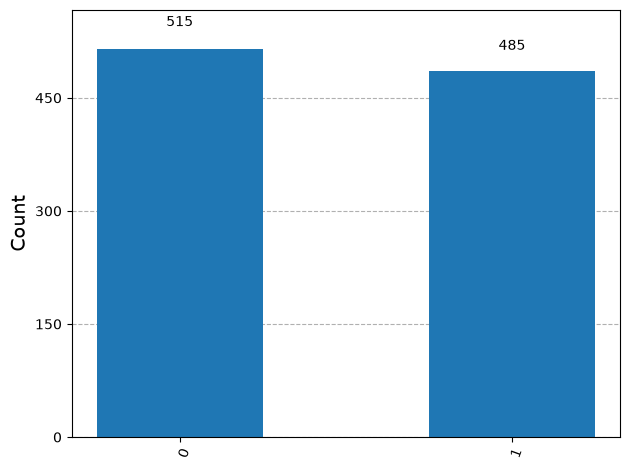

In [14]:
# part 2.4
# demo 1 - data visualization

from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)
qc.measure([0, 1], [0, 1])

from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [15]:
# demo 2 - 2.4 - hadamard shots
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts)

{'0': 506, '1': 494}


In [16]:
# demo 3 - 2.4 - bell shots
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts)

{'00': 532, '11': 468}


In [17]:
# demo 3 - 2.4 - probabilities
shots = sum(counts.values())

probabilities = {
    bitstring: count / shots
    for bitstring, count in counts.items()
}

print(probabilities)

{'00': 0.532, '11': 0.468}


In [23]:
# demo 4 - 2.4 - expected value
counts = {'0': 503, '1': 497}
shots = sum(counts.values())

z_expectation = (
    counts.get('0', 0) - counts.get('1', 0)
) / shots

print(z_expectation)

0.006


In [24]:
# part 2.5
# demo 1 - interference
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)

qc.h(0)
qc.h(0)

state = Statevector.from_instruction(qc)

print(state)
# the final state should resemble the vector for state |0>

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [25]:
# demo 2 - 2.5 - grover diffusion operator
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

# Create uniform superposition
qc.h([0, 1])

# Diffusion operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])

print(qc.draw())

     ┌───┐┌───┐┌───┐   ┌───┐┌───┐
q_0: ┤ H ├┤ H ├┤ X ├─■─┤ X ├┤ H ├
     ├───┤├───┤├───┤ │ ├───┤├───┤
q_1: ┤ H ├┤ H ├┤ X ├─■─┤ X ├┤ H ├
     └───┘└───┘└───┘   └───┘└───┘


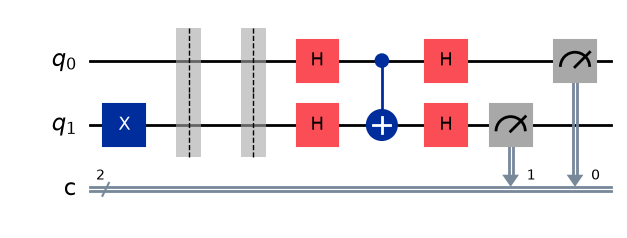

In [14]:
# ASSIGNMENT 2 CODE HERE
# 2 QUBIT SYSTEM
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)
qc.x([1])
qc.barrier([0, 1])
qc.barrier([0, 1])
qc.h([0, 1])
qc.cx(0, 1)
qc.h([0, 1])
qc.measure(1, 1)
qc.measure(0, 0)

qc.draw("mpl")

In [15]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts) # strange.. always outputs 11

{'11': 1000}
